[[ 4.21850347  2.23419161]
 [ 0.90779887  0.45984362]
 [-0.27652528  5.08127768]
 [ 0.08848433  2.32299086]
 [ 3.24329731  1.21460627]
 [ 1.44193252  2.76754364]
 [ 1.0220286   4.11660348]
 [ 3.97820955  2.37817845]
 [ 0.58894326  4.00148458]
 [ 1.25185786  0.20811388]
 [ 0.62835793  4.4601363 ]
 [ 1.68608568  0.65828448]
 [ 1.18454506  5.28042636]
 [ 0.06897171  4.35573272]
 [ 1.78726415  1.70012006]
 [ 4.4384123   1.84214315]
 [ 3.18190344 -0.18226785]
 [ 0.30380963  3.94423417]
 [ 0.73936011  0.43607906]
 [ 1.28535145  1.43691285]
 [ 1.1312175   4.68194985]
 [ 0.66471755  4.35995267]
 [ 1.31570453  2.44067826]
 [-0.18887976  5.20461381]
 [ 2.57854418  0.72611733]
 [ 0.87305123  4.71438583]
 [ 1.3105127   0.07122512]
 [ 0.9867701   6.08965782]
 [ 1.42013331  4.63746165]
 [ 2.3535057   2.22404956]
 [ 2.43169305 -0.20173713]
 [ 1.0427873   4.60625923]
 [ 0.95088418  0.94982874]
 [ 2.45127423 -0.19539785]
 [ 1.62011397  2.74692739]
 [ 2.15504965  4.12386249]
 [ 1.38093486  0.92949422]
 

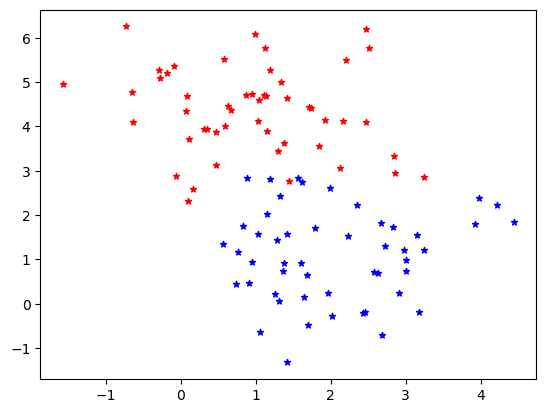

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
import math
from sklearn.datasets import make_blobs
X,Y=make_blobs(n_samples=100,centers=2,random_state=0)
colors=["red","blue"]
print(X)
print(Y)
print(X.shape)
print(Y.shape)
for i,col in enumerate(colors):
    cluster=Y==i
    plt.scatter(X[cluster,0],X[cluster,1],c=col,marker='*',s=20)
Y=Y[:,np.newaxis]


In [38]:
theta=np.random.randn(3,1)
print(theta)

[[ 0.96644022]
 [ 0.33553973]
 [-1.11137481]]


In [39]:
X=np.hstack((np.ones((X.shape[0],1)),X))

In [40]:
print(X.shape)

(100, 3)


In [41]:
def h_theta(X,theta):
    return 1/(1+np.exp(-X.dot(theta)))

In [42]:
def cost(X,Y,theta):
    return -1/len(X)*(np.sum(Y*(np.log(h_theta(X,theta)))+(1-Y)*(np.log(1-h_theta(X,theta)))))

In [43]:
def gradient(X,Y,theta):
    return 1/len(X)*(X.T.dot(h_theta(X,theta)-Y))

In [44]:
def gradient_descent(X,Y,theta,alpha,it):
    cost_history=np.zeros(it)
    new_theta=theta
    for i in range(it):
        new_theta=new_theta-alpha*gradient(X,Y,new_theta)
        cost_history[i]=cost(X,Y,theta)
    return cost_history,new_theta

In [45]:
cost_history,theta=gradient_descent(X,Y,theta,0.001,10000)

In [46]:
print(theta)

[[ 1.46507185]
 [ 1.00959508]
 [-1.24161552]]


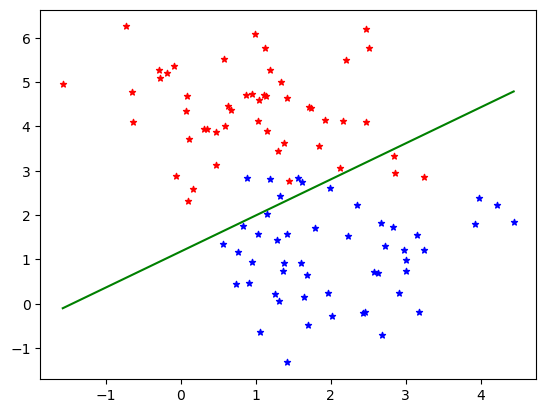

In [47]:
for i, col in enumerate(colors):
    cluster = Y[:, 0] == i
    # نستخدم العمود 1 والعمود 2 (لأن العمود 0 أصبح كله رقم 1)
    plt.scatter(X[cluster, 1], X[cluster, 2], c=col, marker='*', s=20)
    
    # 2. تحديد بداية ونهاية الخط (أصغر وأكبر قيمة في محور السينات x1)
x1_min = np.min(X[:, 1])
x1_max = np.max(X[:, 1])
x1_values = np.array([x1_min, x1_max])
    
    # 3. حساب نقاط محور الصادات للخط باستخدام المعادلة الرياضية التي استنتجناها
    # theta[0] هي نقطة التقاطع، theta[1] لـ x1، و theta[2] لـ x2
x2_values = - (theta[0] + theta[1] * x1_values) / theta[2]
    
    # 4. رسم الخط الفاصل باللون الأخضر
plt.plot(x1_values, x2_values, color='green', label='Decision Boundary')